In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, Lasso
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from statsmodels.stats.mediation import Mediation
from sklearn.svm import SVR
from pingouin import ancova
import matplotlib.cm as cm
from scipy.stats import pearsonr
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

# 1 Load validation set

In [150]:
# load data from pickle and convert to dataframe
brain_test = pd.read_pickle("edu_brain_test_validate.pkl")
main_test = pd.read_pickle("edu_main_test_validate.pkl")
brain_train = pd.read_pickle("1_edu_brain_train.pkl")
brain_test = pd.DataFrame(brain_test)
main_test = pd.DataFrame(main_test)
brain_train = pd.DataFrame(brain_train)

# 2 BrainAGE prediction Combined Destrieux + ASEG

In [151]:
# select Freesurfer ASEG for training data
whole_brain = brain_train.iloc[:,27:70:2]
left_hemi = brain_train.iloc[:,103:134:2]
right_hemi = brain_train.iloc[:,165:196:2]
age = brain_train["Age"]
ASEG_train = pd.DataFrame(pd.concat([whole_brain,left_hemi, right_hemi,age],axis = 1))

# select Freesurfer ASEG for testing data
whole_brain = brain_test.iloc[:,27:70:2]
left_hemi = brain_test.iloc[:,103:134:2]
right_hemi = brain_test.iloc[:,165:196:2]
age = brain_test["Age"]
ASEG_test = pd.DataFrame(pd.concat([whole_brain,left_hemi, right_hemi,age],axis = 1))

ASEG_X_train = ASEG_train.iloc[:,:-1]
ASEG_X_test = ASEG_test.iloc[:,:-1]


# select variables belonging to the A2009s segmentation
Des_X_train = brain_train.iloc[:,1657:2544:2]
Des_X_test = brain_test.iloc[:,1657:2544:2]


# select age
Y_train = brain_train.iloc[:,-1]
Y_test = brain_test.iloc[:,-1]

# Combine ASEG and A2009s for training data
X_train = pd.concat([ASEG_X_train, Des_X_train], axis=1)
Y_train = Y_train

# Combine ASEG and A2009s for testing data
X_test = pd.concat([ASEG_X_test, Des_X_test], axis=1)
Y_test = Y_test

# standardize x-data
X_train = stats.zscore(X_train)
X_test = stats.zscore(X_test)

# set of alphas to try (=penalization)
alpha_parameters = np.power(10,np.linspace(start=-3, stop=5, num=100))

In [152]:
X_CV = X_train
Y_CV = Y_train

# randomly split data (only training no PA) into training and testing set
X_train_cv, X_test_cv, Y_train_cv, Y_test_cv = train_test_split(X_CV,Y_CV)

# define the model
model_ridge = RidgeCV(alphas = alpha_parameters)

# perform 10-fold cross validation
scores_ridge = cross_val_score(model_ridge, X_CV, Y_CV, cv=10, scoring='neg_mean_absolute_error')

# calculate the mean-absolute error
mae_ridge = -1 * scores_ridge.mean()

print("The MAE for cross-validation (Ridge):", mae_ridge)

# for correction
model_ridge.fit(X_train_cv,Y_train_cv)
y_pred_cv = model_ridge.predict(X_test_cv)

The MAE for cross-validation (Ridge): 3.73656425547509


The MAE for testing set using Ridge: 3.831560319167251
Index(['volume_of_putamen_left_hemisphere_f26560_2_0',
       'volume_of_brainstem_whole_brain_f26526_2_0',
       'volume_of_putamen_right_hemisphere_f26591_2_0',
       'volume_of_ventraldc_right_hemisphere_f26596_2_0',
       'volume_of_supratentorialnotvent_whole_brain_f26520_2_0',
       'volume_of_thalamusproper_left_hemisphere_f26558_2_0',
       'volume_of_thalamusproper_right_hemisphere_f26589_2_0',
       'volume_of_supratentorial_whole_brain_f26519_2_0',
       'volume_of_cortex_right_hemisphere_f26583_2_0',
       'volume_of_cortex_left_hemisphere_f26552_2_0',
       'volume_of_totalgray_whole_brain_f26518_2_0',
       'volume_of_brainsegnotvent_whole_brain_f26515_2_0',
       'volume_of_cerebralwhitematter_left_hemisphere_f26553_2_0',
       'volume_of_brainseg_whole_brain_f26514_2_0',
       'volume_of_cerebralwhitematter_right_hemisphere_f26584_2_0',
       'volume_of_subcortgray_whole_brain_f26517_2_0',
       'volu

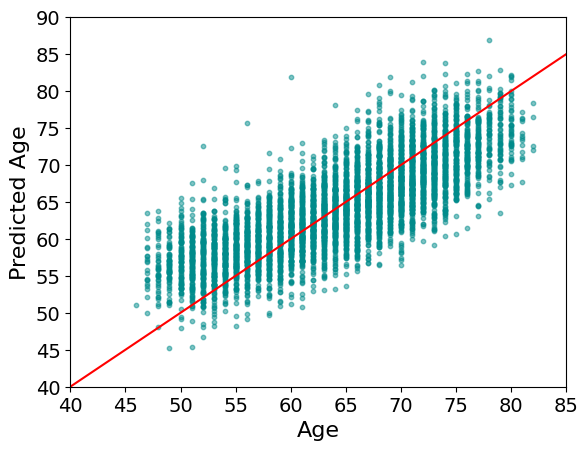

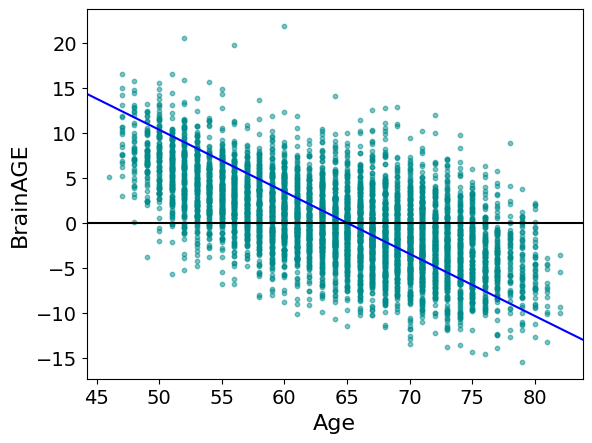

In [153]:
model_Ridge = RidgeCV(alphas = alpha_parameters)

# train model 
model_Ridge.fit(X_train,Y_train)

# get predicted values for test set
y_pred_Ridge = model_Ridge.predict(X_test)

# calculate brain age gap
brain_age_delta_Ridge = y_pred_Ridge-Y_test

# get mean absolute error (MAE)
print("The MAE for testing set using Ridge:", mean_absolute_error(Y_test,y_pred_Ridge))

# top x coefficients and their names
coeff = np.asarray(model_Ridge.coef_)
coeffabs = np.asarray(abs(model_Ridge.coef_))
top_coefficients = np.argsort(coeffabs)[-20:]
print(X_train.iloc[:,top_coefficients].columns)
print(coeff[top_coefficients])

# plot figure with x: actual age Y: predicted age, and a line with slope 1 for reference
plt.figure()
plt.scatter(Y_test, y_pred_Ridge, alpha=0.5, s=10, color = "darkcyan")
plt.axline((60,60), slope=1, color='r')
plt.xticks(range(40,90,5))
plt.yticks(range(40,95,5))
plt.ylabel('Predicted Age', fontsize = 16)
plt.xlabel('Age', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize=14)
plt.show()

# plot the brainAGE and a line with the correlation between brainAGE and age 
plt.figure()
plt.scatter(Y_test,brain_age_delta_Ridge, alpha=0.5, s=10, color = "darkcyan")
plt.axline((65,0), slope=-0.69, color="blue")
plt.axline((60,0),slope=0, color = "black")
plt.ylabel("BrainAGE", fontsize = 16)
plt.xlabel("Age", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize=14)
plt.show()

Coefficient and Intercept: 0.6339341086876721 23.619606274936103


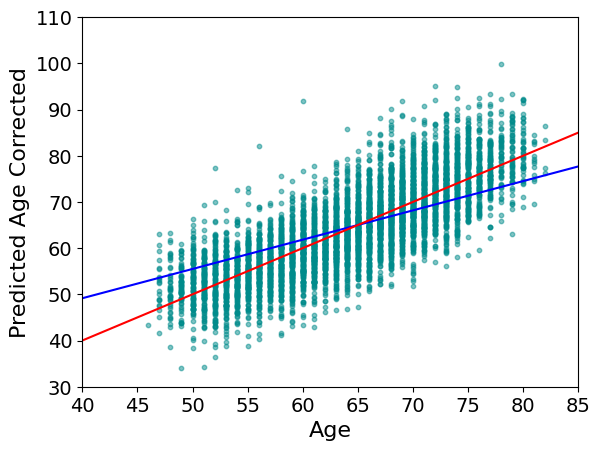

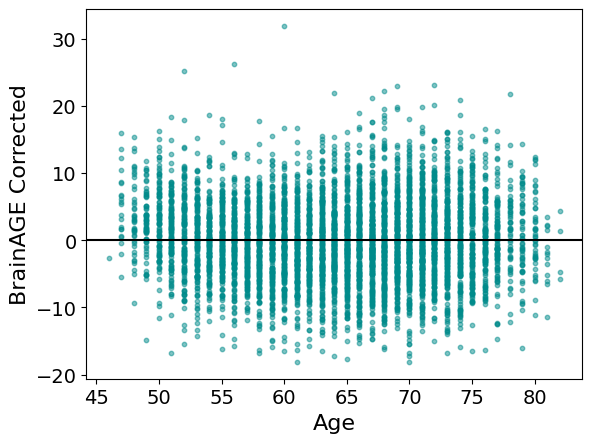

In [154]:
# reformat cross validation data for regression model
y_pred_cv = np.asarray(y_pred_cv)
y_pred_cv = np.reshape(y_pred_cv, (-1,1))
Y_test_cv = np.asarray(Y_test_cv)
Y_test_cv = np.reshape(Y_test_cv, (-1,1))

# now using correction from the R code that's online from Cole
reg = LinearRegression().fit(Y_test_cv, y_pred_cv)
coef = float(reg.coef_)
intercept = float(reg.intercept_)
print("Coefficient and Intercept:", coef, intercept)

# correction by cole
function = lambda t: (t-intercept)/coef
vfunc = np.vectorize(function)
corr_brainage_4 = vfunc(y_pred_Ridge)
corr_brainage_delta_4 = corr_brainage_4-Y_test

# plots corrected
plt.figure()
plt.scatter(Y_test, corr_brainage_4, alpha=0.5, s=10, color="darkcyan")
plt.axline((65,65), slope=coef, color="blue")
plt.ylabel("Predicted Age Corrected", fontsize = 16)
plt.axline((60,60), slope=1, color='r')
plt.xlabel("Age", fontsize = 16)
plt.xticks(range(40,90,5), fontsize = 14)
plt.yticks(range(30,115,10), fontsize = 14)
plt.show()

plt.figure()
plt.scatter(Y_test, corr_brainage_delta_4, alpha=0.5, s=10, color="darkcyan")
plt.axline((60,0),slope=0, color = "black")
plt.ylabel("BrainAGE Corrected", fontsize = 16)
plt.xlabel("Age", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize=14)
plt.show()

In [155]:
main_test["BA"] = corr_brainage_delta_4

# 3 Preprocessing

## 3.1 Recoding

In [156]:
# recoding imaging site and gender
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 0, '11026': 1,'11027': 2, '11028': 3})
main_test["Sex"] = main_test["Sex"].map({"Female":0, "Male":1})
main_test["Sex"] = main_test["Sex"].astype("int")
main_test['EDUL'] = main_test['EDUL'].map({'None of the above': 0, 'Other professional qualifications eg: nursing, teaching': 5,'NVQ or HND or HNC or equivalent': 4, 'CSEs or equivalent': 1, 'O levels/GCSEs or equivalent':2, 'A levels/AS levels or equivalent':3,'College or University degree':6})


# delete unnecessary variables
del main_test["ID"]
del main_test["MVPA"]
del main_test["TPA"]

## 3.2 Remove outliers on SRPA

In [157]:
# remove outliers on self-reported physical activity data for each intensity seperately
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 541
5430


## 3.3 Convert SRPA from MET min/week to min/week

In [158]:
main_test["SRLPA"] = main_test["SRLPA"]/3.3
main_test["SRMPA"] = main_test["SRMPA"]/4
main_test["SRVPA"] = main_test["SRVPA"]/8

# 4 Basic distributions of validation set

## 4.1 Data and Descriptives

In [159]:
main_test.head()

,Age,Sex,IS,VPA,MPA,LPA,SRLPA,SRMPA,SRVPA,HG,HR,BMI,DBP,SBP,EDUL,BA
4736,67.0,1,2,50.4000,796.3200,2016.0000,480.0,150.0,90.0,46.0,74.0,24.1906,78.0,129.0,4.0,NaN
25541,58.0,0,1,29.8080,645.8400,2841.6960,80.0,150.0,50.0,24.0,79.0,21.4902,98.0,144.0,3.0,NaN
34536,71.0,0,0,30.2400,584.6400,1874.8800,180.0,120.0,45.0,26.0,74.0,26.5347,76.0,131.0,6.0,0.997087
26384,63.0,0,0,39.8016,726.3792,2666.7072,300.0,420.0,300.0,24.0,70.0,23.8123,80.0,120.0,2.0,NaN
29280,72.0,1,1,20.1600,655.2000,2570.4000,225.0,150.0,150.0,46.0,67.0,25.2094,74.0,144.0,6.0,-0.077176


In [160]:
# get mean and std for all variables for males and females seperately for the test set
female = main_test[main_test["Sex"] == 0]
male = main_test[main_test["Sex"]== 1]

print("Number of females:", female.shape[0])
print("NUmber of males:", male.shape[0])

print("Age")
mean = main_test["Age"].mean()
print("Mean", mean)
std = main_test["Age"].std()
print("Std",std)

print("LPA")
mean = main_test["LPA"].mean()
print("Mean", mean)
std = main_test["LPA"].std()
print("Std",std)

print("MPA")
mean = main_test["MPA"].mean()
print("Mean", mean)
std = main_test["MPA"].std()
print("Std",std)

print("VPA")
mean = main_test["VPA"].mean()
print("Mean", mean)
std = main_test["VPA"].std()
print("Std",std)

print("SRLPA")
mean = main_test["SRLPA"].mean()
print("Mean", mean)
std = main_test["SRLPA"].std()
print("Std",std)

print("SRMPA")
mean = main_test["SRMPA"].mean()
print("Mean", mean)
std = main_test["SRMPA"].std()
print("Std",std)

print("SRVPA")
mean = main_test["SRVPA"].mean()
print("Mean", mean)
std = main_test["SRVPA"].std()
print("Std",std)

print("DBP")
mean = main_test["DBP"].mean()
print("Mean", mean)
std = main_test["DBP"].std()
print("Std",std)

print("SBP")
mean = main_test["SBP"].mean()
print("Mean", mean)
std = main_test["SBP"].std()
print("Std",std)

print("BMI")
mean = main_test["BMI"].mean()
print("Mean", mean)
std = main_test["BMI"].std()
print("Std",std)

print("HG")
mean = main_test["HG"].mean()
print("Mean", mean)
std = main_test["HG"].std()
print("Std",std)

print("HR")
mean = main_test["HR"].mean()
print("Mean", mean)
std = main_test["HR"].std()
print("Std",std)

print("IS")
print(main_test["IS"].value_counts())

Number of females: 2892
NUmber of males: 2538
Age
Mean 64.34106813996317
Std 7.793195734833509
LPA
Mean 1975.9681458563534
Std 419.33550679785185
MPA
Mean 484.7509843093924
Std 219.08708972840938
VPA
Mean 34.36739801104976
Std 44.93169323082406
SRLPA
Mean 234.053591160221
Std 215.33987554859476
SRMPA
Mean 158.47845303867405
Std 190.68951337197254
SRVPA
Mean 65.73167587476979
Std 83.51505065605785
DBP
Mean 81.11491712707182
Std 10.354681605432472
SBP
Mean 136.67292817679558
Std 18.476217808463943
BMI
Mean 26.24153893186004
Std 4.1888258945476915
HG
Mean 33.788766114180476
Std 10.952102847183022
HR
Mean 67.83499079189687
Std 10.962537319834826
IS
0    3426
2    1077
1     917
3      10
Name: IS, dtype: int64


## 4.3 Physical activity

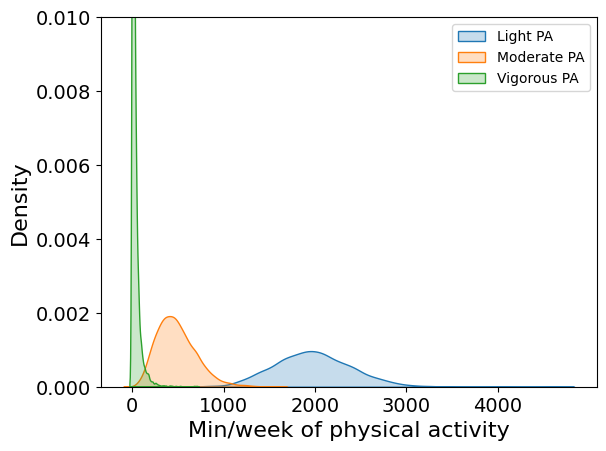

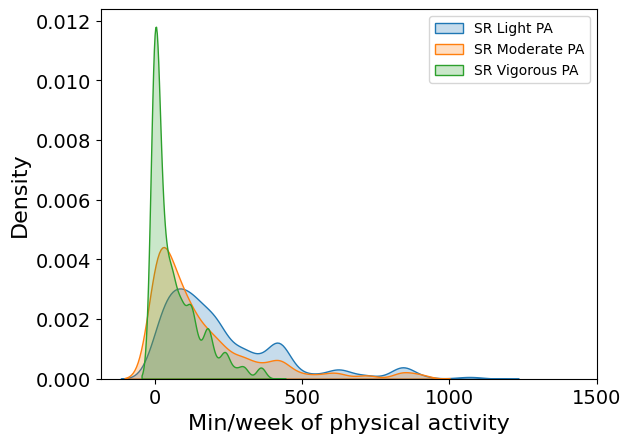

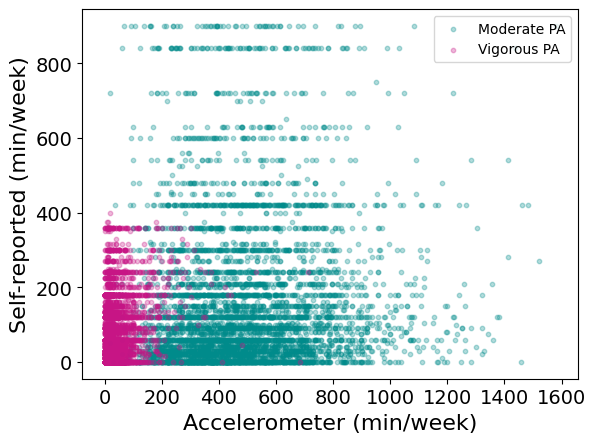

In [161]:
# plot physical activity intensity categories for self-report and accelerometer together and seperately

plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,5000,1000),fontsize = 14)
plt.ylim(0,0.01)
plt.ylabel("Density",fontsize = 16)
plt.yticks(fontsize = 14)
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity", fontsize = 16)
plt.xticks(range(0,2000,500),fontsize = 14)
plt.yticks(fontsize = 14)
plt.ylabel("Density",fontsize = 16)
plt.legend()
plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
# sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,4500,1000),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
# sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.xticks(range(0,2500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.legend()
# plt.show()

# plt.figure()
# sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
# sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
# plt.ylim(0,0.01)
# plt.xticks(range(0,1500,500),fontsize = 14)
# plt.yticks(fontsize = 14)
# plt.ylabel("Density",fontsize = 16)
# plt.xlabel("Min/week of physical activity", fontsize = 16)
# plt.legend()
# plt.show()

plt.figure()
plt.scatter("MPA", "SRMPA", data = main_test, label = "Moderate PA", alpha=0.3, s=10, color = "darkcyan")
plt.scatter("VPA", "SRVPA", data = main_test, label = "Vigorous PA", alpha=0.3, s=10, color = "mediumvioletred")
plt.ylabel("Self-reported (min/week)", fontsize = 16)
plt.xlabel("Accelerometer (min/week)", fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc="best")
plt.show()

# 5 Reorder Dataframe

In [162]:
# reorder dataframe
main_test = main_test[['Age', 'Sex', 'IS' ,"EDUL", 'LPA', 'MPA', 'VPA', 'SRLPA', 'SRMPA', 'SRVPA', 'HG', 'HR', 'BMI', 'DBP', 'SBP', 'BA']]

In [163]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS", "EDUL"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS", "EDUL"]], nan_policy='omit')

# 6 Correlation Heatmap

In [164]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

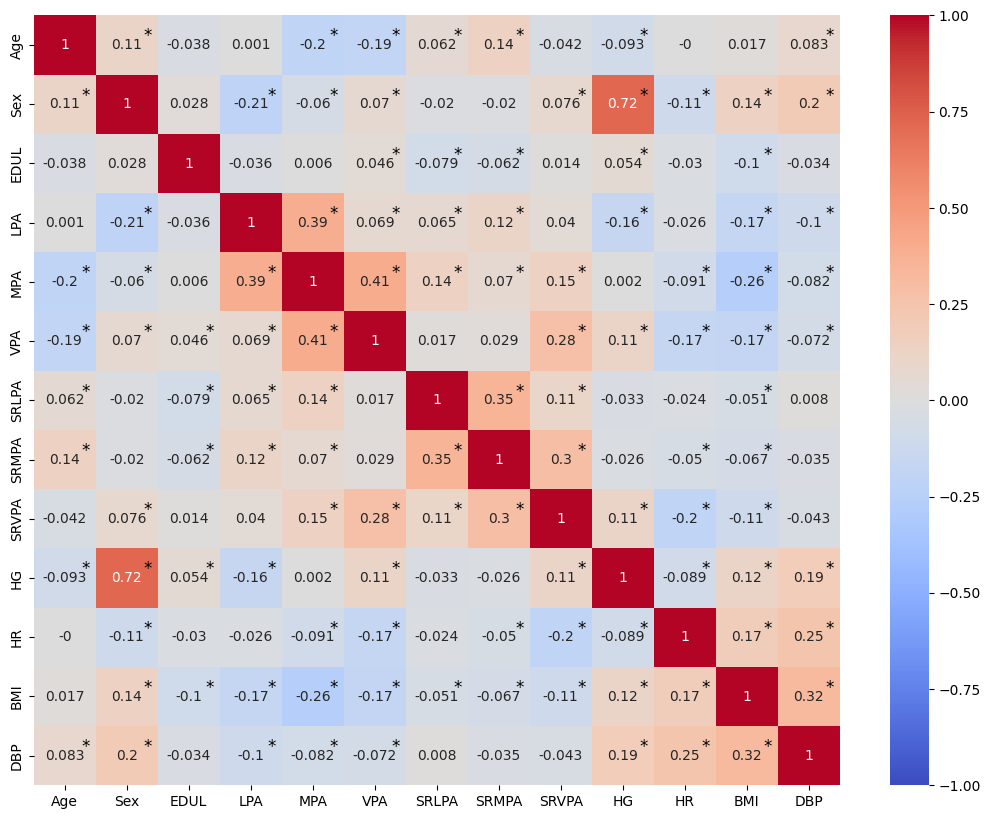

In [165]:
corr_test = main_test
corr_test = corr_test[:]
del corr_test["BA"]
del corr_test["SBP"]
del corr_test["IS"]
corr = corr_test.corr()
corr = round(corr,3)

fig, ax = plt.subplots(figsize=(13,10)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)


p_values = np.asarray(calculate_pvalues(corr_test))

threshold = 0.0007575  # Define your significance threshold

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        if i != j:
            correlation = corr.iloc[i, j]
            p_value = p_values[i,j]  # Calculate or provide the p-value for the correlation

            if p_value < threshold:
                ax.text(j + 0.9, i + 0.2, "*", ha='right', va='top', color='black', fontsize=12)

# 7 Models with OLS

## 7.1 Baseline Covariates

In [166]:
cov_model = ols('BA ~ Sex + Age + IS + EDUL', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     3.521
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00713
Time:                        22:34:20   Log-Likelihood:                -8705.0
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2710   BIC:                         1.745e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0410      0.115     -0.357      0.7

## 7.2 Accelerometer PA

In [167]:
lpa = ols('BA ~ LPA + Age + Sex + IS + EDUL + Sex:LPA + EDUL:LPA', missing='drop', data = main_test).fit()
print(lpa.summary())

#calculate effect size
results = lpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     3.191
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00229
Time:                        22:34:20   Log-Likelihood:                -8700.9
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2707   BIC:                         1.746e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0471      0.117     -0.403      0.6

In [168]:
mpa = ols('BA ~ MPA + Sex + Age + EDUL + IS + Sex:MPA + EDUL:MPA', missing='drop', data = main_test).fit()
print(mpa.summary())

#calculate effect size
results = mpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.855
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00572
Time:                        22:34:20   Log-Likelihood:                -8702.0
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2707   BIC:                         1.747e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0524      0.115     -0.456      0.6

In [169]:
vpa = ols('BA ~ VPA + Age + Sex + IS + EDUL + Sex:VPA + EDUL:VPA', missing='drop', data = main_test).fit()
print(vpa.summary())

#calculate effect size
results = vpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     2.818
Date:                Fri, 29 Nov 2024   Prob (F-statistic):            0.00632
Time:                        22:34:20   Log-Likelihood:                -8702.2
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2707   BIC:                         1.747e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0241      0.115     -0.209      0.8

## 7.3 Self-report PA

In [170]:
srlpa = ols('BA ~ SRLPA + Age + Sex + IS + EDUL + EDUL:SRLPA + Sex:SRLPA', missing='drop', data = main_test).fit()
print(srlpa.summary())

#calculate effect size
results = srlpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.544
Date:                Fri, 29 Nov 2024   Prob (F-statistic):             0.0131
Time:                        22:34:20   Log-Likelihood:                -8703.1
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2707   BIC:                         1.747e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0325      0.115     -0.281      0.7

In [171]:
srmpa = ols('BA ~ SRMPA + Sex + Age + IS + EDUL + EDUL:SRMPA + Sex:SRMPA', missing='drop', data = main_test).fit()
print(srmpa.summary())

#calculate effect size
results = srmpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.498
Date:                Fri, 29 Nov 2024   Prob (F-statistic):             0.0148
Time:                        22:34:20   Log-Likelihood:                -8703.3
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2707   BIC:                         1.747e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0254      0.115     -0.221      0.8

In [172]:
srvpa = ols('BA ~ SRVPA + Age + Sex + IS + EDUL + EDUL:SRVPA + Sex:SRVPA', missing='drop', data = main_test).fit()
print(srvpa.summary())

#calculate effect size
results = srvpa
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5452))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     2.396
Date:                Fri, 29 Nov 2024   Prob (F-statistic):             0.0192
Time:                        22:34:20   Log-Likelihood:                -8703.6
No. Observations:                2715   AIC:                         1.742e+04
Df Residuals:                    2707   BIC:                         1.747e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0377      0.115     -0.327      0.7

# 8 Model comparisons

## 8.1 Cov vs. PA

In [173]:
model_comparison = anova_lm(cov_model, lpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff        F    Pr(>F)
0    2710.0  96875.410800      0.0         NaN      NaN       NaN
1    2707.0  96581.915569      3.0  293.495231  2.74203  0.041769


In [174]:
model_comparison = anova_lm(cov_model, mpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0    2710.0  96875.410800      0.0         NaN       NaN       NaN
1    2707.0  96665.147172      3.0  210.263628  1.962733  0.117449


In [175]:
model_comparison = anova_lm(cov_model, vpa)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    2710.0  96875.41080      0.0        NaN       NaN       NaN
1    2707.0  96674.31112      3.0  201.09968  1.877013  0.131281


## 8.2 Cov vs. SRPA

In [176]:
model_comparison = anova_lm(cov_model, srlpa)
print(model_comparison)

   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0    2710.0  96875.410800      0.0         NaN       NaN       NaN
1    2707.0  96742.336781      3.0  133.074019  1.241206  0.293121


In [177]:
model_comparison = anova_lm(cov_model, srmpa)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    2710.0  96875.41080      0.0        NaN       NaN       NaN
1    2707.0  96753.96209      3.0  121.44871  1.132638  0.334448


In [178]:
model_comparison = anova_lm(cov_model, srvpa)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    2710.0  96875.41080      0.0       NaN       NaN       NaN
1    2707.0  96779.20222      3.0  96.20858  0.897013  0.441895


# 10 Standardization of all variables

In [179]:
main_test = pd.DataFrame(main_test)
main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS", "EDUL"]] = stats.zscore(main_test[["LPA", "MPA","VPA","SRLPA","SRMPA","SRVPA","HR", "DBP", "SBP", "HG","BMI","Age","Sex","IS", "EDUL"]], nan_policy='omit')

# 11 Mediation analysis

## 11.1 BMI

In [180]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "LPA").fit()
# print(res.summary())

In [181]:
outcome_model = sm.OLS.from_formula("BA ~ BMI + MPA + Age + Sex + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("BMI ~ MPA + Age + Sex + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "MPA").fit()
print(res.summary())

modelm = ols("BMI ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ BMI + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.047764       -0.114212        0.012734    0.120
ACME (treated)           -0.047764       -0.114212        0.012734    0.120
ADE (control)            -0.059226       -0.290798        0.172273    0.610
ADE (treated)            -0.059226       -0.290798        0.172273    0.610
Total effect             -0.106990       -0.333839        0.119426    0.368
Prop. mediated (control)  0.259422       -3.879523        4.203066    0.452
Prop. mediated (treated)  0.259422       -3.879523        4.203066    0.452
ACME (average)           -0.047764       -0.114212        0.012734    0.120
ADE (average)            -0.059226       -0.290798        0.172273    0.610
Prop. mediated (average)  0.259422       -3.879523        4.203066    0.452
                            OLS Regression Results                            
Dep. Variable:                    BMI   R-squared:                       0.097
Model:

In [182]:
# outcome_model = sm.OLS.from_formula("BA ~ BMI + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("BMI ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "BMI", exposure = "VPA").fit()
# print(res.summary())

## 11.2 DBP

In [183]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "LPA").fit()
# print(res.summary())

In [184]:
outcome_model = sm.OLS.from_formula("BA ~ DBP + MPA + Age + Sex + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("DBP ~ MPA + Age + Sex + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "MPA").fit()
print(res.summary())

modelm = ols("DBP ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ DBP + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.038651       -0.081285       -0.002315    0.036
ACME (treated)           -0.038651       -0.081285       -0.002315    0.036
ADE (control)            -0.076929       -0.295631        0.160009    0.552
ADE (treated)            -0.076929       -0.295631        0.160009    0.552
Total effect             -0.115580       -0.339121        0.119647    0.320
Prop. mediated (control)  0.215522       -3.832692        5.341347    0.340
Prop. mediated (treated)  0.215522       -3.832692        5.341347    0.340
ACME (average)           -0.038651       -0.081285       -0.002315    0.036
ADE (average)            -0.076929       -0.295631        0.160009    0.552
Prop. mediated (average)  0.215522       -3.832692        5.341347    0.340
                            OLS Regression Results                            
Dep. Variable:                    DBP   R-squared:                       0.050
Model:

In [185]:
# outcome_model = sm.OLS.from_formula("BA ~ DBP + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("DBP ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "DBP", exposure = "VPA").fit()
# print(res.summary())

## 11.3 Heart rate

In [186]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + LPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ LPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "LPA").fit()
# print(res.summary())

In [187]:
outcome_model = sm.OLS.from_formula("BA ~ HR + MPA + Age + Sex + IS + EDUL", main_test)
mediator_model = sm.OLS.from_formula("HR ~ MPA + Age + Sex + IS + EDUL", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HR ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HR + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.036832       -0.070632       -0.010329    0.000
ACME (treated)           -0.036832       -0.070632       -0.010329    0.000
ADE (control)            -0.075638       -0.325575        0.167707    0.514
ADE (treated)            -0.075638       -0.325575        0.167707    0.514
Total effect             -0.112470       -0.357431        0.130847    0.356
Prop. mediated (control)  0.207368       -3.020658        2.126818    0.356
Prop. mediated (treated)  0.207368       -3.020658        2.126818    0.356
ACME (average)           -0.036832       -0.070632       -0.010329    0.000
ADE (average)            -0.075638       -0.325575        0.167707    0.514
Prop. mediated (average)  0.207368       -3.020658        2.126818    0.356
                            OLS Regression Results                            
Dep. Variable:                     HR   R-squared:                       0.023
Model:

In [188]:
# outcome_model = sm.OLS.from_formula("BA ~ HR + VPA + Age + Gender", main_test)
# mediator_model = sm.OLS.from_formula("HR ~ VPA + Age + Gender", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HR", exposure = "VPA").fit()
# print(res.summary())

## 11.4 Hand grip

In [189]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + LPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ LPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "LPA").fit()
# print(res.summary())

In [190]:
outcome_model = sm.OLS.from_formula("BA ~ HG + MPA + Sex + IS + EDUL + Age", main_test)
mediator_model = sm.OLS.from_formula("HG ~ MPA + Sex + IS + EDUL + Age", main_test)
res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "MPA").fit()
print(res.summary())

modelm = ols("HG ~ MPA + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modelm.summary())
modely = ols("BA ~ HG + Age + Sex + IS + EDUL", missing='drop', data = main_test).fit()
print(modely.summary())

                          Estimate  Lower CI bound  Upper CI bound  P-value
ACME (control)           -0.003066       -0.019031        0.009947    0.640
ACME (treated)           -0.003066       -0.019031        0.009947    0.640
ADE (control)            -0.115846       -0.326425        0.110349    0.296
ADE (treated)            -0.115846       -0.326425        0.110349    0.296
Total effect             -0.118912       -0.326972        0.104762    0.292
Prop. mediated (control)  0.010205       -0.334837        0.407152    0.744
Prop. mediated (treated)  0.010205       -0.334837        0.407152    0.744
ACME (average)           -0.003066       -0.019031        0.009947    0.640
ADE (average)            -0.115846       -0.326425        0.110349    0.296
Prop. mediated (average)  0.010205       -0.334837        0.407152    0.744
                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.557
Model:

In [191]:
# outcome_model = sm.OLS.from_formula("BA ~ HG + VPA + Gender + Age", main_test)
# mediator_model = sm.OLS.from_formula("HG ~ VPA + Gender + Age", main_test)
# res = Mediation(outcome_model, mediator_model, mediator = "HG", exposure = "VPA").fit()
# print(res.summary())

# 12 LASSO Regression

## 12.1 Accelerometer PA

Optimal alpha: 0.11497569953977356


<Figure size 1200x900 with 0 Axes>

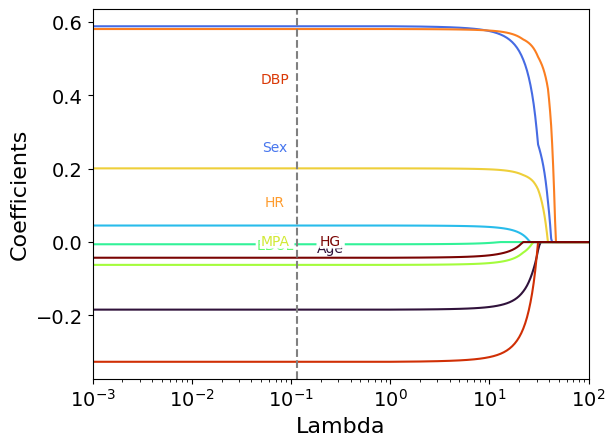

[-0.          0.22471326  0.         -0.         -0.          0.10648823
  0.4815619  -0.          0.        ]
0.015254034909090497


In [192]:
df = main_test[["Age", "Sex", "IS", "EDUL", "MPA", "SRMPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Sex", "IS", "EDUL", "MPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Sex", "IS", "EDUL", "MPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)

# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 7.0)
    if i == 0:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(100, -7),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(60, 6),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(60, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(60, -13),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(60, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(60, -5),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(100, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i ==5:
        plt.annotate(column, (1e-2, y_pos), textcoords="offset points", xytext=(60, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white',edgecolor="white", pad=0))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 100)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend().set_visible(False)
plt.show()

# Print the coefficients
print(coefficients)
print(r_squared)

## 12.2 Self-report PA

Optimal alpha: 0.12328467394420659


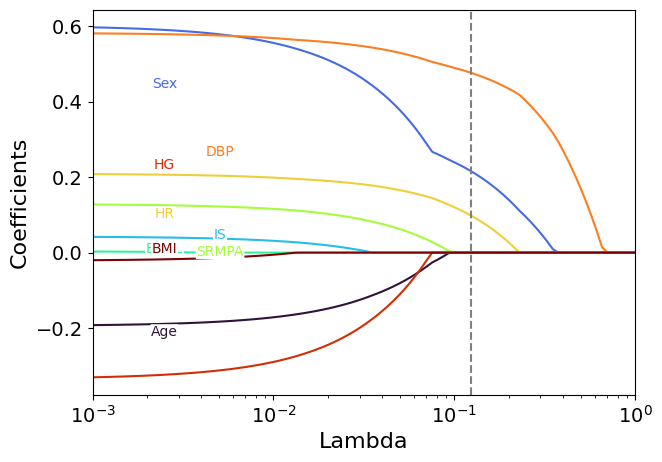

[-0.          0.21646613  0.         -0.          0.          0.09873795
  0.47699474 -0.          0.        ]
0.015117428233804686


In [193]:
df = main_test[["Age", "Sex",  "IS", "EDUL", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Sex",  "IS", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Sex", "IS", "EDUL", "SRMPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=0, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('turbo')
plt.figure(figsize=(7,5))
for i, column in enumerate(columns):
    plt.plot(alphas, coefs[column], label=column, color=cmap(i / (len(columns) - 1)))

# lasso with cross validated alpha
lassocv = LassoCV(alphas = alphas).fit(X,Y)
best_alpha = lassocv.alpha_
print("Optimal alpha:", best_alpha)


# Get the coefficients of the Lasso model at the best lambda value
lasso = Lasso(alpha=best_alpha)
lasso.fit(X, Y)
coefficients = lasso.coef_
r_squared = lasso.score(X,Y)

for i, column in enumerate(columns):
    y_pos = coefficients[i]
    color = cmap(i / 8.0)
    if i == 0:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -60),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 1:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 60),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 2:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(40, 10),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 3:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 4:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(40, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 5:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, -2),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 6:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(40, -60),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 7:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 60),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))
    elif i == 8:
        plt.annotate(column, (0.0025, y_pos), textcoords="offset points", xytext=(0, 0),
                     ha='center', fontsize=10, color=color, bbox=dict(boxstyle='round', facecolor='white', edgecolor="white", pad=0))


plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Lambda', fontsize = 16)
plt.axvline(x = best_alpha, color = 'gray', linestyle='dashed')
plt.xlim(0.001, 1)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend().set_visible(False)
plt.show()


# Print the coefficients
print(coefficients)
print(r_squared)